# 4.1) Univariate Exploration

Deep dive into individual variables: distributions, outliers, patterns, temporal trends, and feature engineering opportunities.


In [9]:
# Inputs: processed latest | Process: load SATNAV | Outputs: satnav_df
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

processed_dir = Path("../data/processed")
candidates = sorted(processed_dir.glob("satnav_*.csv"))
csv_path = candidates[-1] if candidates else processed_dir / "satnav_latest.csv"

satnav_df = pd.read_csv(csv_path)
print("Loaded:", csv_path)
print("Shape:", satnav_df.shape)


Loaded: ../data/processed/satnav_latest.csv
Shape: (65088, 41)


In [31]:
# Explore String type categorical data
# Barplots of counts and boxplots (IQRs) by category

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- Editable settings ---
# categorical_features: String/categorical columns to visualize
categorical_features = ['rcs_size', 'object_type', 'site']

# numeric_metric: Numeric column to show distribution (IQR) in boxplots
numeric_metric = 'rev_at_epoch'  # Change to e.g., 'apogee', 'perigee', 'launch_year'

# top_n_categories: Limit to top N most frequent categories to keep plots readable
top_n_categories = 15

# show_fliers: Whether to show outlier points in boxplots
show_fliers = False
# -------------------------

# Validate numeric column
if numeric_metric not in satnav_df.columns:
    raise KeyError(f"Column '{numeric_metric}' not found. Available: {list(satnav_df.columns)}")


IQR for 'rev_at_epoch' by 'rcs_size':
              IQR
rcs_size         
SMALL     63060.0
LARGE     16223.5
nan        2686.5
MEDIUM    30288.0


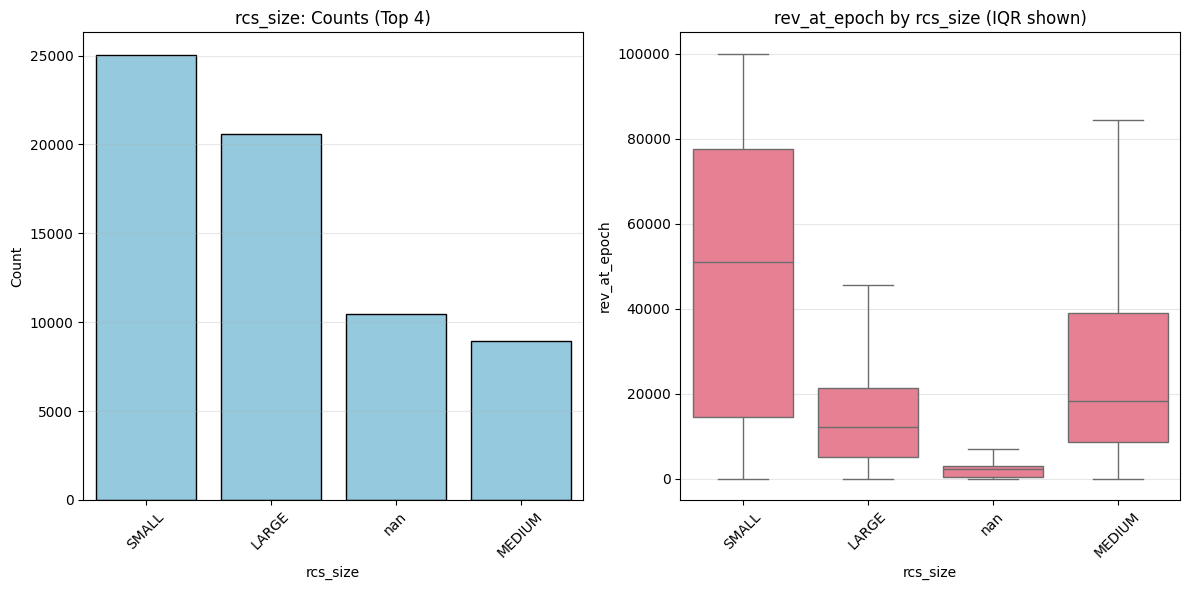

IQR for 'rev_at_epoch' by 'object_type':
                  IQR
object_type          
DEBRIS       61662.00
PAYLOAD      16075.00
ROCKET BODY  35598.75
UNKNOWN      10663.00


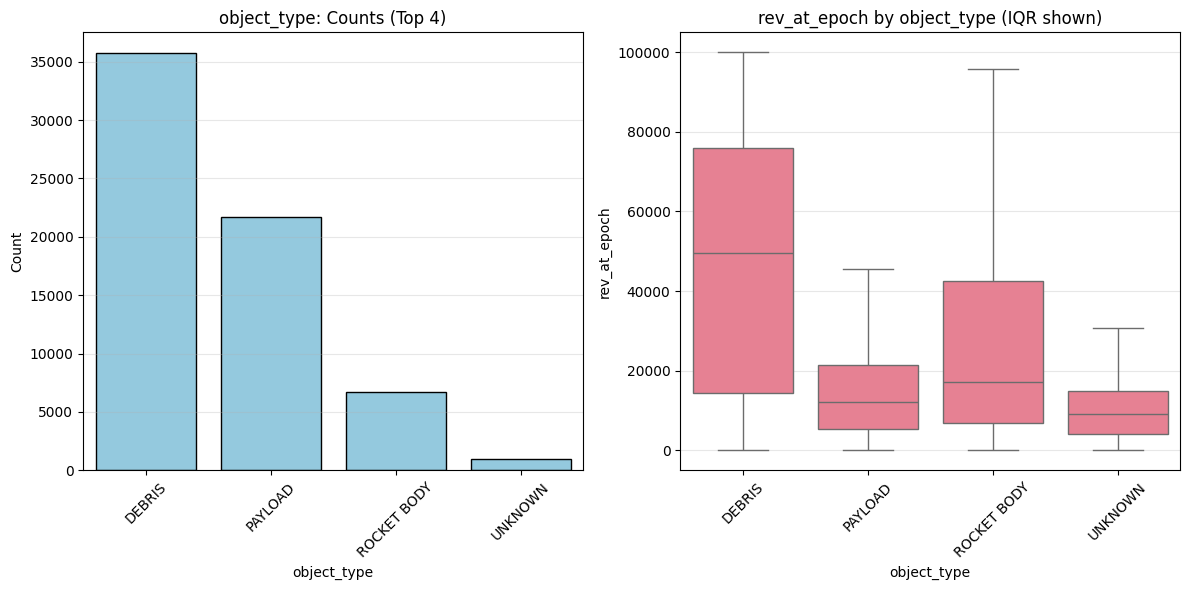

IQR for 'rev_at_epoch' by 'site':
            IQR
site           
PKMTR  54344.00
TTMTR  47968.00
AFETR  14808.00
AFWTR  42751.50
TSC    80528.75
FRGUI  15807.00
SRI    30930.00
JSC    35772.00
XSC     6824.75
TNSTA  44137.50
VOSTO  10246.00
KYMTR     73.50
RLLC   14592.00
WLPIS  32160.75
WSC     3054.75


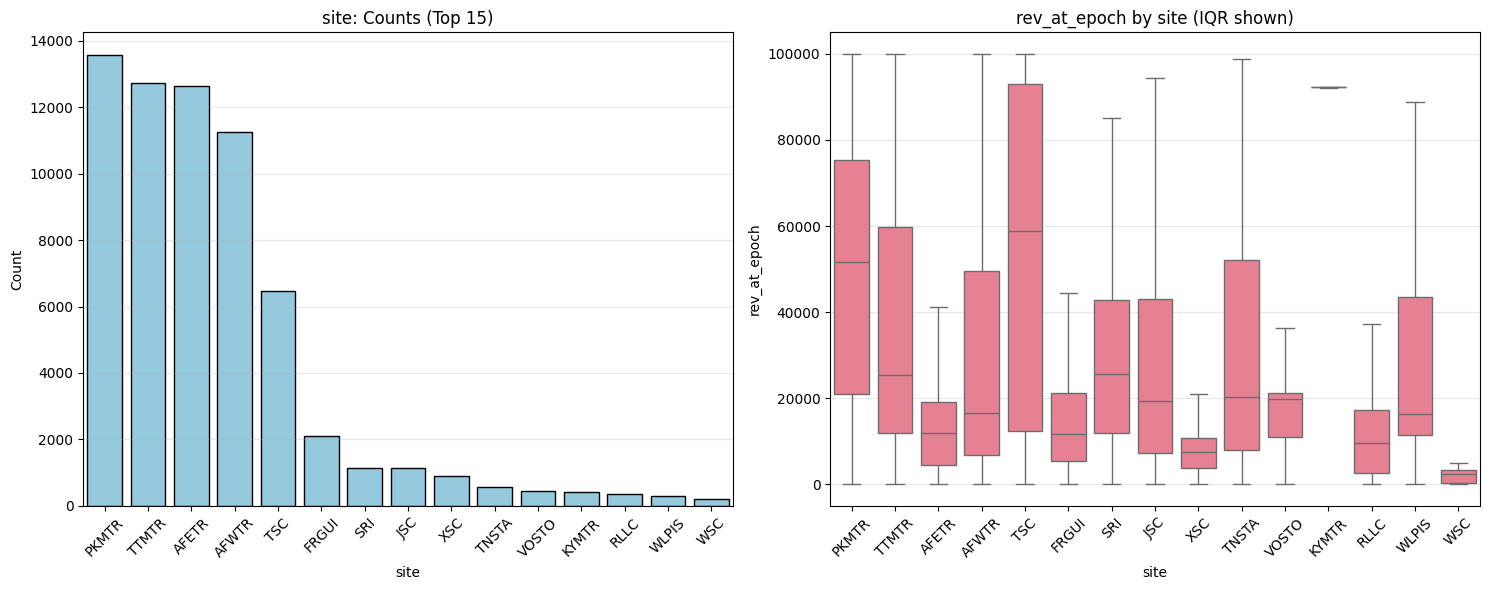

In [32]:

# Ensure numeric_metric is numeric
_numeric = pd.to_numeric(satnav_df[numeric_metric], errors='coerce')

for col in categorical_features:
    if col not in satnav_df.columns:
        print(f"Skipping '{col}' (column not found)")
        continue

    counts = satnav_df[col].value_counts(dropna=False)
    if counts.empty:
        print(f"Skipping '{col}' (no data)")
        continue

    # Select top categories and prepare plotting order
    top_counts = counts.head(top_n_categories)
    category_order = [str(c) for c in top_counts.index.tolist()]

    # Prepare DataFrame for boxplot
    df_plot = pd.DataFrame({col: satnav_df[col].astype(str), numeric_metric: _numeric})
    df_plot = df_plot[df_plot[col].isin(category_order) & df_plot[numeric_metric].notna()].copy()

    # Dynamic width based on number of categories
    n_cat = len(category_order)
    fig_width = max(12, min(28, 0.6 * n_cat + 6))
    fig, axes = plt.subplots(1, 2, figsize=(fig_width, 6))

    # Barplot of counts
    sns.barplot(
        x=[str(c) for c in top_counts.index],
        y=top_counts.values,
        ax=axes[0],
        color='skyblue',
        edgecolor='black'
    )
    axes[0].set_title(f"{col}: Counts (Top {n_cat})")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(True, axis='y', alpha=0.3)

    # Boxplot for numeric_metric by category (shows IQR)
    if not df_plot.empty:
        sns.boxplot(
            data=df_plot,
            x=col,
            y=numeric_metric,
            order=category_order,
            showfliers=show_fliers,
            ax=axes[1]
        )
        axes[1].set_title(f"{numeric_metric} by {col} (IQR shown)")
        axes[1].set_xlabel(col)
        axes[1].set_ylabel(numeric_metric)
        axes[1].tick_params(axis='x', rotation=45)
        axes[1].grid(True, axis='y', alpha=0.3)

        # Print IQRs in console for reference
        q = df_plot.groupby(col)[numeric_metric].quantile([0.25, 0.75]).unstack()
        q.columns = ['Q1', 'Q3']
        q['IQR'] = (q['Q3'] - q['Q1']).round(2)
        q = q.reindex(category_order)
        print(f"IQR for '{numeric_metric}' by '{col}':")
        print(q[['IQR']].to_string())
    else:
        axes[1].set_visible(False)
        print(f"No numeric data available for boxplot of '{col}' vs '{numeric_metric}'.")

    plt.tight_layout()
    plt.show()

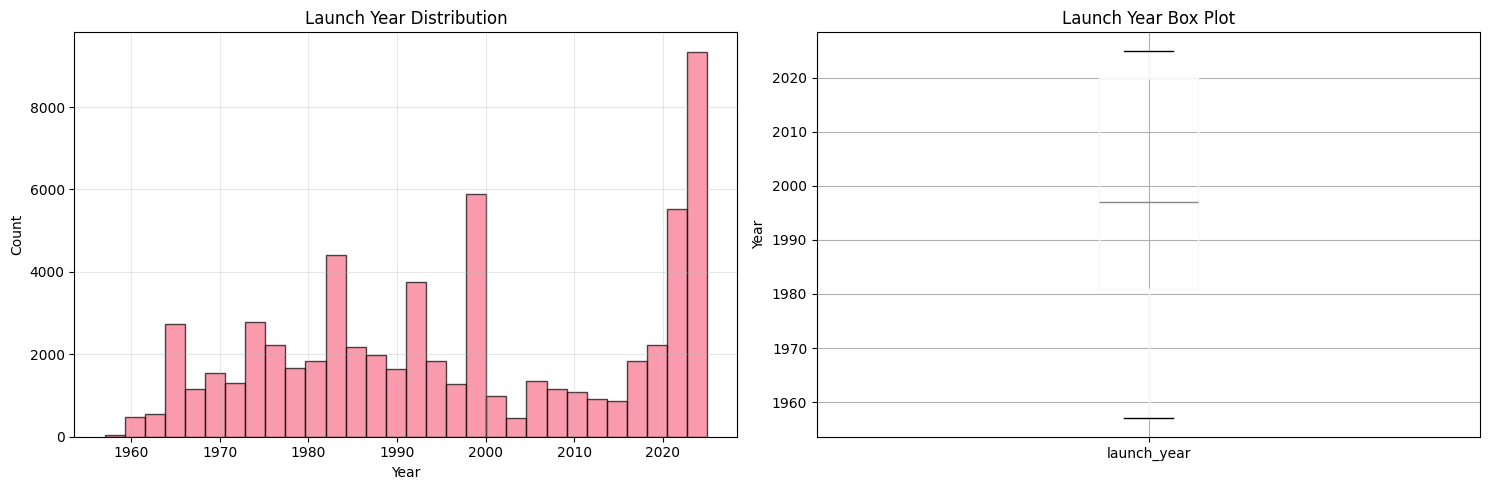

Launch year stats:
count    65088.000000
mean      1997.252305
std         19.674968
min       1957.000000
25%       1981.000000
50%       1997.000000
75%       2020.000000
max       2025.000000
Name: launch_year, dtype: float64


In [ ]:
# Inputs: satnav_df | Process: launch year distribution | Outputs: histogram + stats
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

iterate = ['launch_year', 'decay', 'decay_date']
# Histogram
satnav_df['launch_year'].hist(bins=30, ax=ax1, alpha=0.7, edgecolor='black')
ax1.set_title('Launch Year Distribution')
ax1.set_xlabel('Year')
ax1.set_ylabel('Count')
ax1.grid(True, alpha=0.3)

# Box plot
satnav_df.boxplot(column='launch_year', ax=ax2)
ax2.set_title('Launch Year Box Plot')
ax2.set_ylabel('Year')

plt.tight_layout()
plt.show()

print("Launch year stats:")
print(satnav_df['launch_year'].describe())


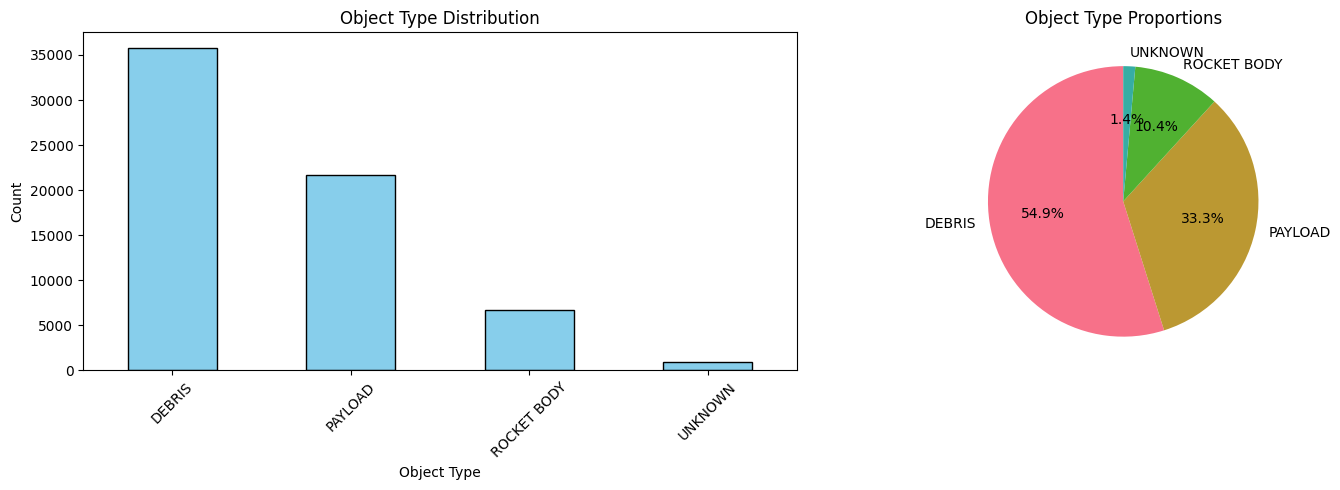

Object type breakdown:
object_type
DEBRIS         35725
PAYLOAD        21695
ROCKET BODY     6737
UNKNOWN          931
Name: count, dtype: int64

Total: 65,088


In [3]:
# Inputs: satnav_df | Process: object type distribution | Outputs: bar chart + proportions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Count plot
obj_counts = satnav_df['object_type'].value_counts()
obj_counts.plot(kind='bar', ax=ax1, color='skyblue', edgecolor='black')
ax1.set_title('Object Type Distribution')
ax1.set_xlabel('Object Type')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=45)

# Pie chart
obj_counts.plot(kind='pie', ax=ax2, autopct='%1.1f%%', startangle=90)
ax2.set_title('Object Type Proportions')
ax2.set_ylabel('')

plt.tight_layout()
plt.show()

print("Object type breakdown:")
print(obj_counts)
print(f"\nTotal: {obj_counts.sum():,}")


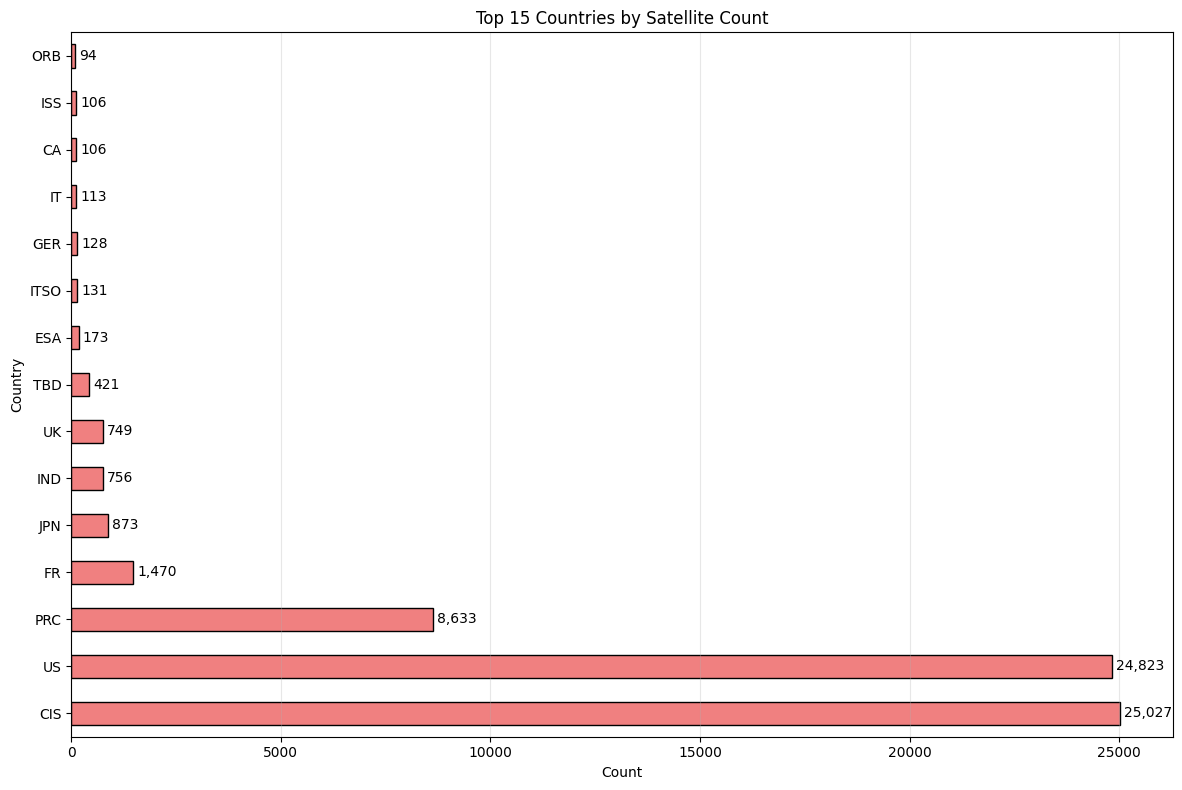

Total countries: 121
Top 3: {'CIS': 25027, 'US': 24823, 'PRC': 8633}


In [38]:
# Inputs: satnav_df | Process: country distribution (top 15) | Outputs: horizontal bar chart
plt.figure(figsize=(12, 8))

country_counts = satnav_df['country'].value_counts().head(15)
country_counts.plot(kind='barh', color='lightcoral', edgecolor='black')
plt.title('Top 15 Countries by Satellite Count')
plt.xlabel('Count')
plt.ylabel('Country')
plt.grid(True, alpha=0.3, axis='x')

# Add count labels
for i, v in enumerate(country_counts.values):
    plt.text(v + 100, i, f'{v:,}', va='center')

plt.tight_layout()
plt.show()

print(f"Total countries: {satnav_df['country'].nunique()}")
print(f"Top 3: {country_counts.head(3).to_dict()}")


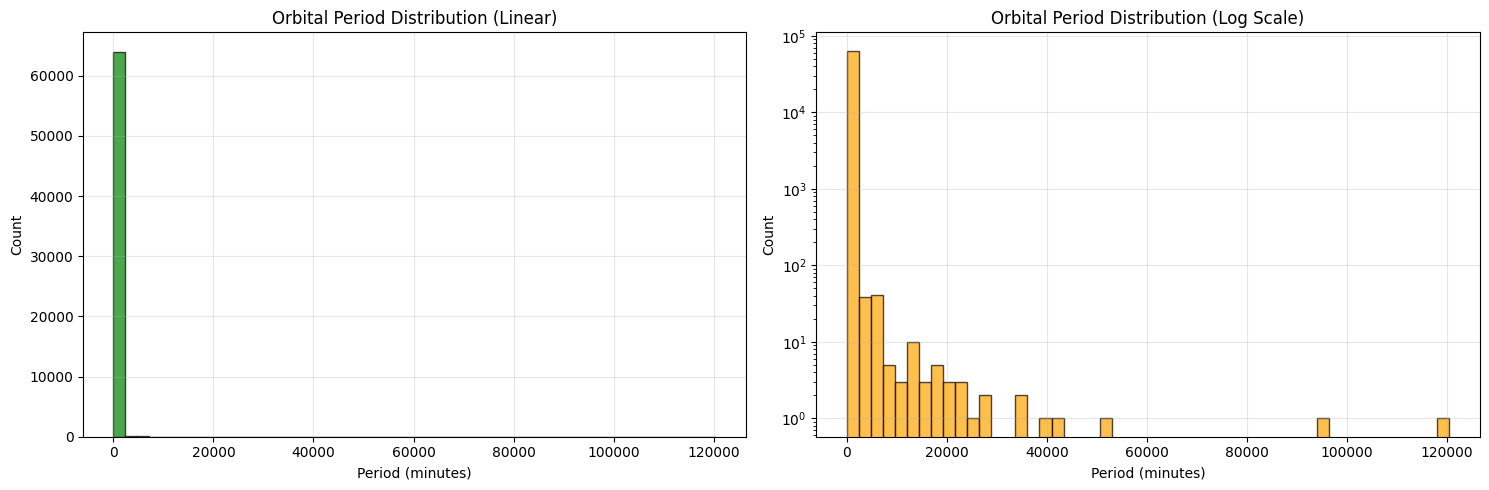

Period stats (minutes):
count     64125.000000
mean        181.398575
std         860.972235
min           0.000000
25%          89.240000
50%          94.106000
75%         101.059000
max      120458.546000
Name: period, dtype: float64

GEO-like periods (1400-1450 min): 1231
LEO-like periods (90-120 min): 38063


In [8]:
# Inputs: satnav_df | Process: orbital period distribution | Outputs: histogram + log scale
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

period_data = satnav_df['period'].dropna()

# Linear scale
period_data.hist(bins=50, ax=ax1, alpha=0.7, edgecolor='black', color='green')
ax1.set_title('Orbital Period Distribution (Linear)')
ax1.set_xlabel('Period (minutes)')
ax1.set_ylabel('Count')
ax1.grid(True, alpha=0.3)

# Log scale
period_data.hist(bins=50, ax=ax2, alpha=0.7, edgecolor='black', color='orange')
ax2.set_title('Orbital Period Distribution (Log Scale)')
ax2.set_xlabel('Period (minutes)')
ax2.set_ylabel('Count')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Period stats (minutes):")
print(period_data.describe())
print(f"\nGEO-like periods (1400-1450 min): {((period_data >= 1400) & (period_data <= 1450)).sum()}")
print(f"LEO-like periods (90-120 min): {((period_data >= 90) & (period_data <= 120)).sum()}")


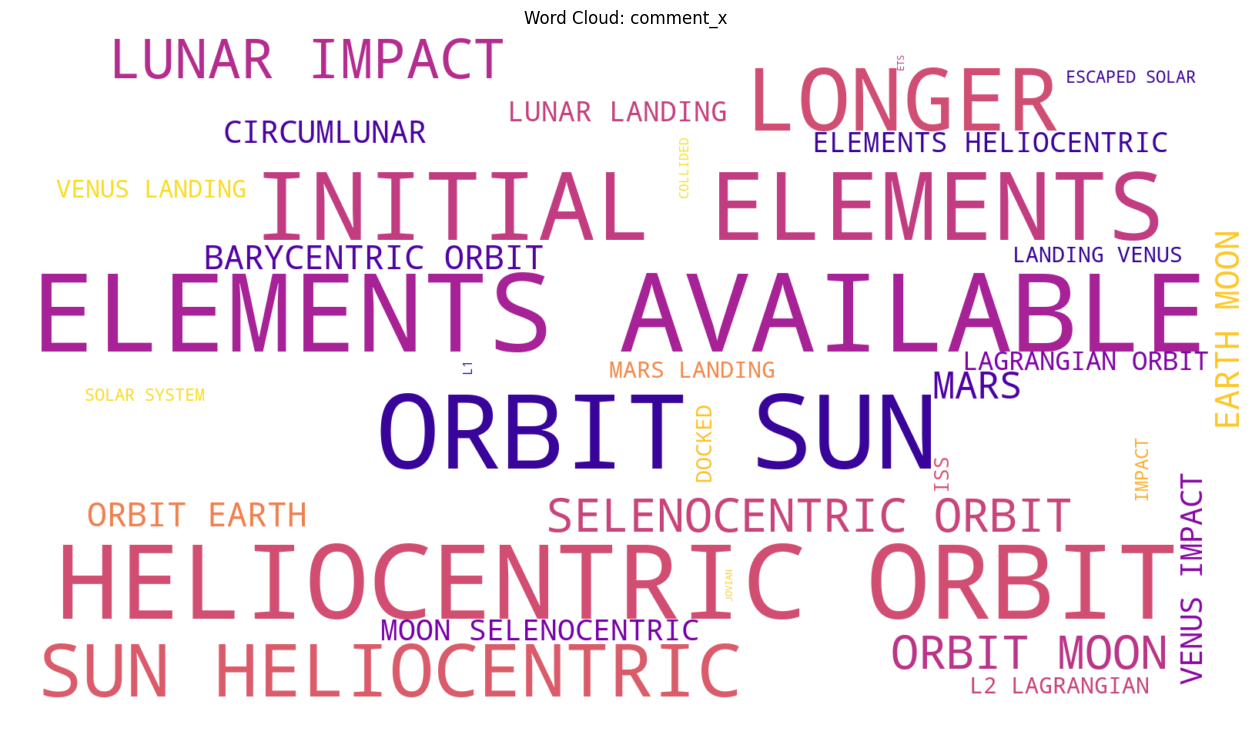

In [44]:
# Inputs: satnav_df | Process: generate word cloud from SatName | Outputs: word cloud figure
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import numpy as np

# --- Editable settings ---
# text_column: Name of the column to use for the word cloud text
text_column = 'comment_x'  # Change to another text column if needed

# max_words: Maximum number of words to display in the cloud
max_words = 100  # Reduce for a sparser cloud, increase for denser

# background_color: Background color of the word cloud image
background_color = 'white'  # e.g., 'black', 'white', '#0f0f0f'

# colormap: Matplotlib colormap for word colors
colormap = 'plasma'  # e.g., 'plasma', 'inferno', 'tab20', 'Set2'

# width, height: Output image size in pixels
width, height = 1600, 900  # Increase for higher resolution output

# stopwords_extra: Extra words to remove (domain-specific or frequent tokens)
stopwords_extra = {
    'SAT', 'SATELLITE', 'OBJECT', 'STARLINK', 'BLOCK', 'COSMOS', 'NAVSTAR', 'ONEWEB',
    'R/B', 'DEB', 'RESURS', 'SHIJIAN', 'FENGYUN', 'ZHUHAI', 'TECHNOLOGY', 'SERIES'
}  # Add/remove words as needed'''
# -------------------------

# Build stopwords set
stopwords = set(STOPWORDS)
stopwords |= {w.lower() for w in stopwords_extra}

# Prepare text: join non-null values from the selected column
if text_column not in satnav_df.columns:
    raise KeyError(f"Column '{text_column}' not found in DataFrame. Available: {list(satnav_df.columns)}")

names_series = satnav_df[text_column].dropna().astype(str)
# Normalize: uppercase to reduce duplicates like 'Starlink' vs 'STARLINK'; remove trivial tokens
processed_text = ' '.join(name.upper() for name in names_series if name.strip())

# Generate word cloud
wc = WordCloud(
    width=width,
    height=height,
    background_color=background_color,
    stopwords=stopwords,
    max_words=max_words,
    colormap=colormap,
    collocations=True,  # Set False to treat bigrams as separate words
    normalize_plurals=True,
).generate(processed_text)

# Display
plt.figure(figsize=(width/100, height/100))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title(f"Word Cloud: {text_column}")
plt.show()


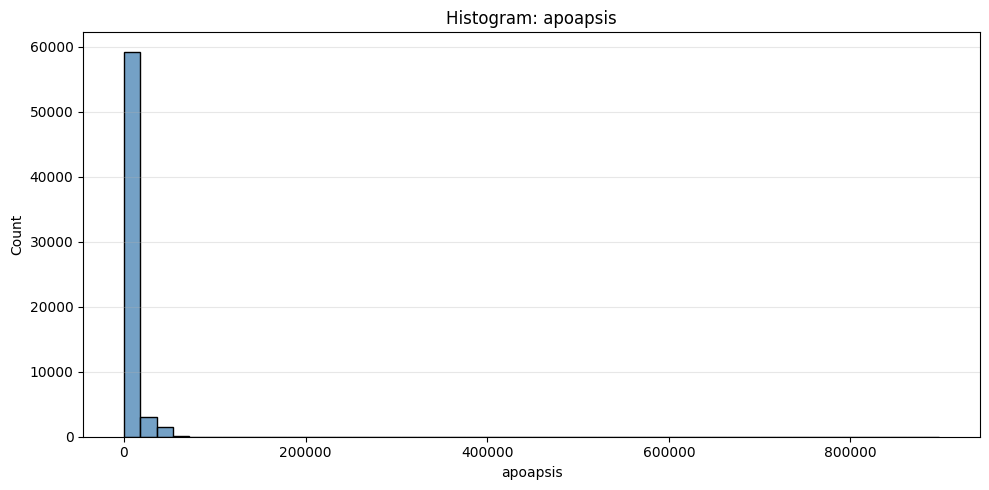

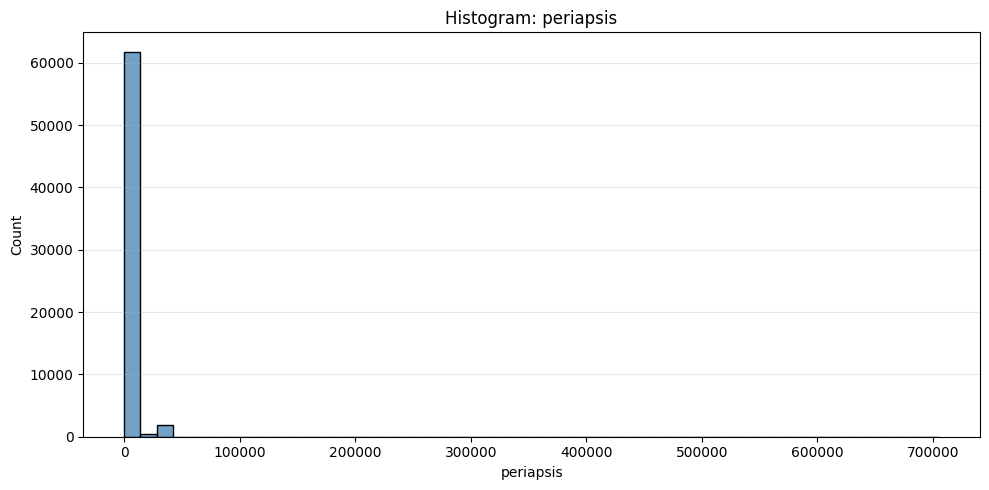

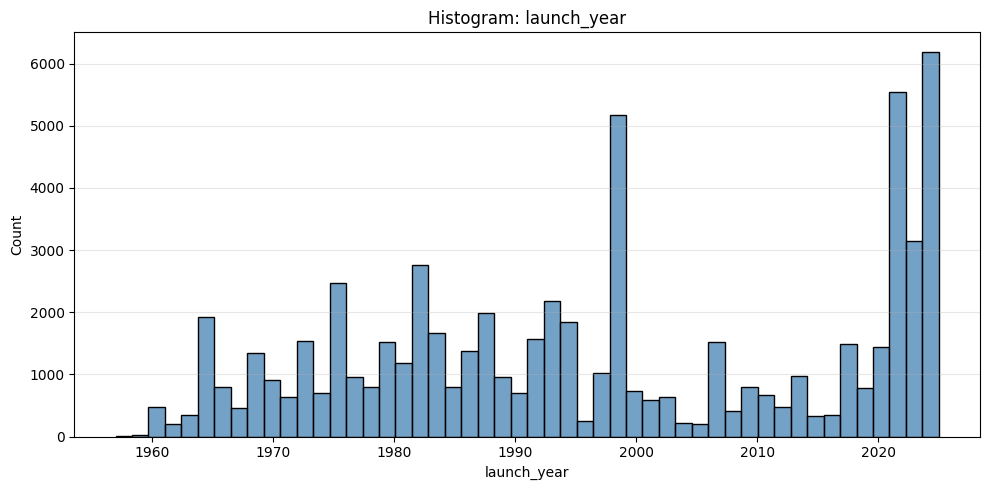

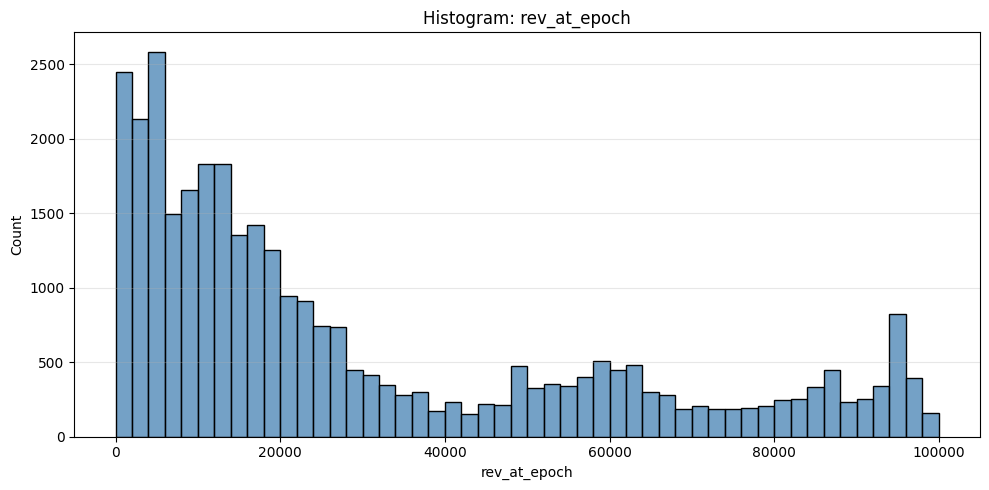

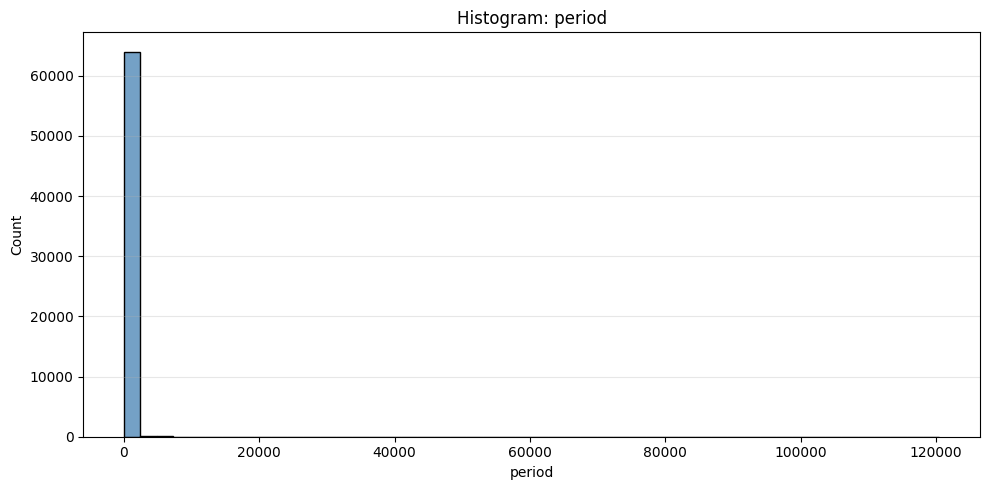

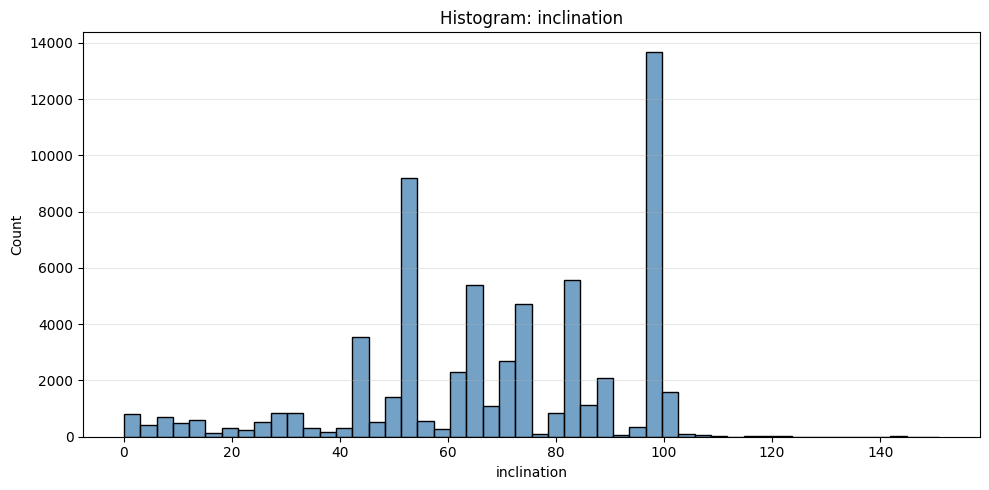

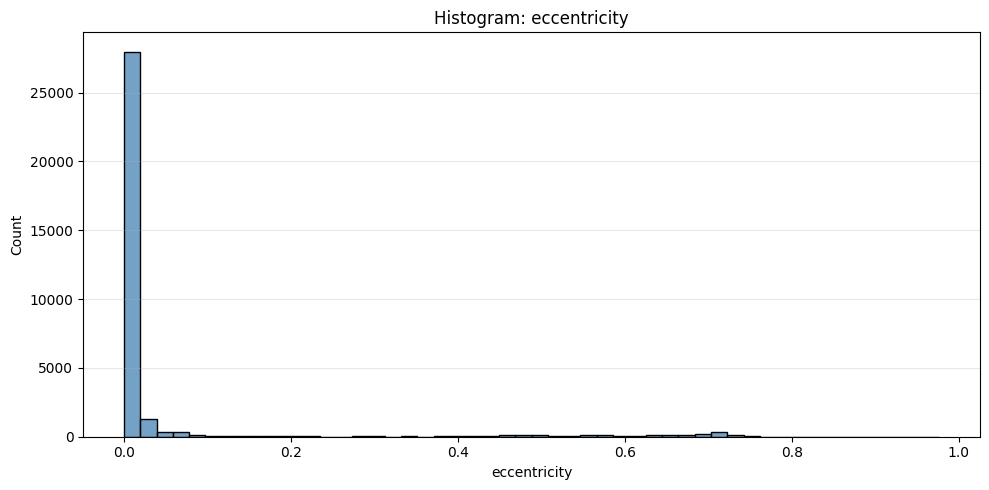

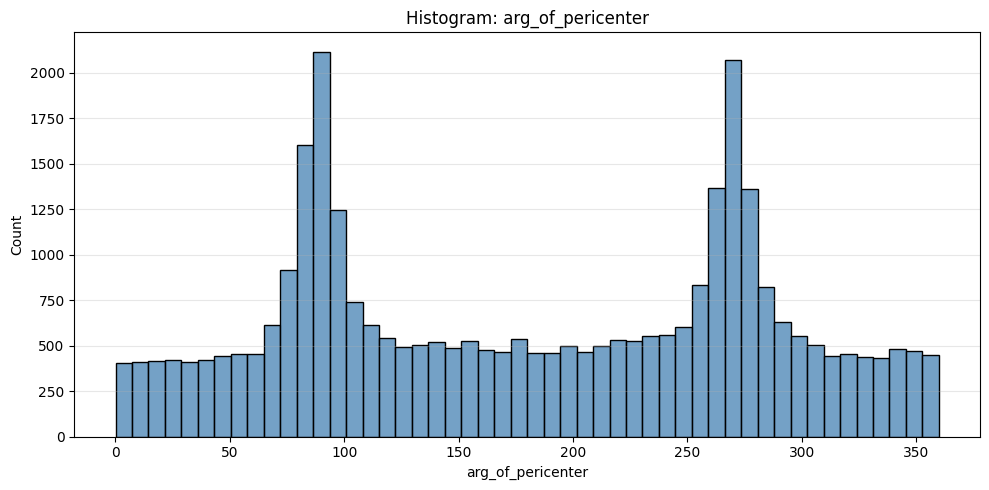

Skipping '': no matching column found among ['']


In [36]:
# Inputs: satnav_df | Process: iterate list and plot histograms | Outputs: seaborn histograms
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# --- Editable settings ---
# explore_dist: columns to explore via histograms
explore_dist = ['apoapsis', 'periapsis', 'launch_year', 'rev_at_epoch', 'period', 
'inclination', 'eccentricity', 'arg_of_pericenter', 
'']

# bins: number of histogram bins
bins = 50

# log_scale: apply log scale to y-axis for skewed distributions
log_scale = False
# -------------------------

# Optional alias mapping to handle alternative column names
alias_map = {
    'apoapsis': ['apoapsis', 'apogee'],
    'periapsis': ['periapsis', 'perigee'],
    'launch_year': ['launch_year', 'LAUNCH_YEAR']
}

for key in explore_dist:
    # Resolve column name via aliases
    candidates = alias_map.get(key, [key])
    col = next((c for c in candidates if c in satnav_df.columns), None)
    if col is None:
        print(f"Skipping '{key}': no matching column found among {candidates}")
        continue

    series = pd.to_numeric(satnav_df[col], errors='coerce').dropna()
    if series.empty:
        print(f"Skipping '{col}': no numeric data to plot")
        continue

    plt.figure(figsize=(10, 5))
    sns.histplot(series, bins=bins, kde=False, color='steelblue', edgecolor='black')
    plt.title(f"Histogram: {col}")
    plt.xlabel(col)
    plt.ylabel('Count')
    if log_scale:
        plt.yscale('log')
    plt.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
